# Sweep Analysis Notebook

This notebook loads and analyzes results from hyperparameter sweeps.

## New Sweep Format (Feb 2026+)

Sweeps created by `sweep_dynamic.py` now have the following structure:
- `sweep_metadata.json` - Contains sweep configuration and arguments
- `results_summary.json` - Contains all experiment results
- `exp_001/`, `exp_002/`, etc. - Individual experiment folders containing:
  - `config.json` - Full training configuration
  - `sweep_config.json` - Sweep-specific hyperparameters
  - `history.json` - Training history
  - `best_model.pth` - Best model checkpoint

The notebook automatically detects the format and loads data accordingly.

In [157]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from itertools import product
from datetime import datetime
from pathlib import Path
import json

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg
from thesis_project.models.components.layers import LowRankPointwiseConv1d
from thesis_project.utils.compute_macs import compute_macs_base_model, compute_avg_rank_from_macs

In [158]:
# Helper to find latest sweep folders
def find_latest_sweeps(base_dir="/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic", n=5):
    """Find the n most recent sweep folders."""
    base_path = Path(base_dir)
    sweep_dirs = [d for d in base_path.iterdir() if d.is_dir() and d.name.startswith("sweep_")]
    
    # Sort by modification time (most recent first)
    sweep_dirs.sort(key=lambda x: x.stat().st_mtime, reverse=True)
    
    print(f"Found {len(sweep_dirs)} sweep folders")
    print(f"\nMost recent {min(n, len(sweep_dirs))} sweeps:")
    for i, sweep_dir in enumerate(sweep_dirs[:n], 1):
        # Try to load metadata to show info
        metadata_path = sweep_dir / "sweep_metadata.json"
        info = ""
        if metadata_path.exists():
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
                timestamp = metadata.get('timestamp', 'unknown')
                loss_types = metadata.get('args', {}).get('loss_types', [])
                num_exp = metadata.get('num_experiments', 0)
                info = f"[{timestamp[:19]}] {loss_types} ({num_exp} experiments)"
        
        print(f"{i}. {sweep_dir.name}")
        if info:
            print(f"   {info}")
    
    return [str(d) for d in sweep_dirs[:n]]

# Uncomment to find latest sweeps
# latest_sweeps = find_latest_sweeps(n=5)

In [159]:
# Helper to compute effective rank accounting for router overhead
def compute_effective_rank(expected_rank, runtime_info, base_model):
    """
    Convert expected_rank (dynamic model avg rank) to effective_rank 
    (equivalent base model rank accounting for router overhead).
    
    Args:
        expected_rank: Average rank used by the dynamic model
        runtime_info: Runtime info dict from experiment (contains router MACs)
        base_model: Base model instance for MAC calculations
        
    Returns:
        Effective rank (equivalent base model rank)
    """
    try:
        # Get router overhead from runtime_info
        router_macs = runtime_info['macs']['router']
        n_stacks = runtime_info['base_model_info']['n_stacks']
        
        # Compute MACs for dynamic model at expected_rank
        # Each stack uses expected_rank on average
        ranks_per_stack = [int(expected_rank)] * n_stacks
        dynamic_model_macs = compute_macs_base_model(
            base_model,
            time_steps=63,
            rank_pr_stack=ranks_per_stack
        )
        
        # Total MACs = dynamic model + router overhead
        total_macs = dynamic_model_macs + router_macs
        
        # Convert back to equivalent base model rank
        effective_rank = compute_avg_rank_from_macs(
            base_model,
            time_steps=63,
            macs=total_macs,
            num_stacks=n_stacks
        )
        
        return effective_rank
    
    except Exception as e:
        print(f"Warning: Could not compute effective rank: {e}")
        return expected_rank  # Fallback to expected rank

In [160]:
def load_sweep_results(sweep_folder):
    """
    Load sweep results from the new format with sweep_metadata.json and results_summary.json.
    Each experiment is in exp_XXX folder with history.json and sweep_config.json.
    """
    sweep_path = Path(sweep_folder)
    
    if not sweep_path.exists():
        print(f"Error: Sweep folder {sweep_folder} does not exist")
        return []
    
    # Check if this is new format (has sweep_metadata.json)
    metadata_path = sweep_path / "sweep_metadata.json"
    results_summary_path = sweep_path / "results_summary.json"
    
    if not metadata_path.exists() or not results_summary_path.exists():
        print(f"Warning: {sweep_folder} doesn't contain sweep_metadata.json or results_summary.json")
        print("Trying to load from old format...")
        return load_sweep_results_old_format(sweep_path)
    
    # Load metadata
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    # Load results summary
    with open(results_summary_path, 'r') as f:
        results_summary = json.load(f)
    
    print(f"Loaded sweep from {metadata['timestamp']}")
    print(f"Total experiments: {metadata['num_experiments']}")
    
    # Analyze experiment_configs to determine what was actually swept
    experiment_configs = metadata.get('experiment_configs', [])
    
    # Collect all unique values for each parameter
    param_values = {}
    for exp_config in experiment_configs:
        for key, value in exp_config.items():
            if key not in param_values:
                param_values[key] = set()
            # Handle unhashable types
            if isinstance(value, (list, dict)):
                param_values[key].add(str(value))
            else:
                param_values[key].add(value)
    
    # Separate swept vs fixed parameters
    swept_params = {k: sorted(v) if not all(isinstance(x, str) and x.startswith('[') for x in v) else v 
                    for k, v in param_values.items() if len(v) > 1}
    fixed_params = {k: list(v)[0] for k, v in param_values.items() if len(v) == 1}
    
    # Show common configuration (fixed across all runs)
    print(f"\n{'─'*80}")
    print("COMMON CONFIGURATION (same for all runs):")
    print(f"{'─'*80}")
    base_config = metadata.get('base_config', {})
    
    # Router config (only show params not varied in sweep)
    router = base_config.get('router', {})
    print(f"  Router:")
    print(f"    Hidden dim: {router.get('hidden_dim')}")
    print(f"    GRU layers: {router.get('num_gru_layers')}")
    print(f"    Pool mode: {router.get('pool_mode')}")
    print(f"    Pool reduction: {router.get('pool_reduction_factor')}")
    print(f"    Last layer bias init: {router.get('last_layer_bias_init')}")
    
    # Training config
    training = base_config.get('training', {})
    if training:
        print(f"  Training:")
        print(f"    Epochs: {training.get('num_epochs')}")
        print(f"    Learning rate: {training.get('init_learning_rate')}")
        print(f"    Optimizer: {training.get('optimizer')}")
        print(f"    Scheduler: {training.get('scheduler')}")
    
    # Data loader
    data_loader = base_config.get('data_loader', {})
    if data_loader:
        print(f"  Data:")
        print(f"    Batch size: {data_loader.get('batch_size')}")
        print(f"    Validation SNRs: {data_loader.get('val_snr_values')}")
    
    # Model config
    dynamic_model = base_config.get('dynamic_model', {})
    if dynamic_model:
        print(f"  Model:")
        print(f"    Freeze base: {dynamic_model.get('freeze_base')}")
        print(f"    Base model: {dynamic_model.get('base_model_dir', '').split('/')[-1]}")
    
    # Noise config
    noise_train = base_config.get('noise_train', {})
    if noise_train:
        print(f"  Noise (train):")
        print(f"    Add noise: {noise_train.get('add_noise')}")
        print(f"    Noise prob: {noise_train.get('noise_prob')}")
        print(f"    SNR range: {noise_train.get('snr')}")
    
    # Show swept parameters
    print(f"\n{'─'*80}")
    print("SWEPT PARAMETERS (varied across runs):")
    print(f"{'─'*80}")
    
    if 'loss_type' in swept_params:
        print(f"  Loss types: {swept_params['loss_type']}")
    elif 'loss_type' in fixed_params:
        print(f"  Loss type: {fixed_params['loss_type']} (fixed)")
    
    if 'rank_weight' in swept_params:
        print(f"  Rank weights: {swept_params['rank_weight']}")
    
    if 'rank_target' in swept_params:
        print(f"  Rank targets: {swept_params['rank_target']}")
    
    if 'router_mode' in swept_params:
        print(f"  Router modes: {swept_params['router_mode']}")
    
    # Show any other swept parameters
    other_swept = {k: v for k, v in swept_params.items() 
                   if k not in ['loss_type', 'rank_weight', 'rank_target', 'router_mode']}
    if other_swept:
        print(f"  Other varied parameters:")
        for key, values in other_swept.items():
            print(f"    {key}: {values}")
    
    print(f"{'─'*80}\n")
    
    # Load base model for effective rank calculations
    # Get base model path from first experiment
    first_exp_path = sweep_path / "exp_001"
    with open(first_exp_path / "config.json", 'r') as f:
        first_config = json.load(f)
    
    base_model_dir_str = first_config['dynamic_model']['base_model_dir']
    base_model_dir = Path(base_model_dir_str)
    
    # Make path absolute if it's relative
    if not base_model_dir.is_absolute():
        # Assume it's relative to the project root
        project_root = Path("/Users/christoffer/Documents/Thesis/thesis_project")
        base_model_dir = project_root / base_model_dir
    
    # Try different config file names
    base_model_config_path = None
    for config_name in ['base_config.json', 'config.yaml', 'config.json']:
        candidate_path = base_model_dir / config_name
        if candidate_path.exists():
            base_model_config_path = candidate_path
            break
    
    if base_model_config_path is None:
        raise FileNotFoundError(f"Could not find base model config in {base_model_dir}")
    
    # Load base model config
    from thesis_project.models.keyword_spotting.base_schema import KeyWordSpottingBaseConfig
    with open(base_model_config_path, 'r') as f:
        if base_model_config_path.suffix == '.yaml':
            base_model_cfg_dict = yaml.safe_load(f)
        else:
            base_model_cfg_dict = json.load(f)
    base_model_cfg = KeyWordSpottingBaseConfig(**base_model_cfg_dict)
    
    # Create base model (just for structure, don't need weights)
    base_model = KWSBase(base_model_cfg)
    
    sweep_results = []
    
    for result_entry in results_summary:
        if not result_entry['success']:
            print(f"Warning: Experiment {result_entry['exp_number']} failed, skipping...")
            continue
        
        exp_config = result_entry['config']
        metrics = result_entry['metrics']
        
        # Load runtime_info.json for effective rank calculation
        exp_path = sweep_path / f"exp_{result_entry['exp_number']:03d}"
        runtime_info_path = exp_path / "runtime_info.json"
        
        with open(runtime_info_path, 'r') as f:
            runtime_info = json.load(f)
        
        # Compute effective rank (accounting for router overhead)
        expected_rank = metrics.get('train_expected_rank')
        router_macs = runtime_info['macs']['router']
        n_stacks = runtime_info['base_model_info']['n_stacks']
        
        if expected_rank is not None:
            effective_rank = compute_effective_rank(expected_rank, runtime_info, base_model)
            
            # Compute MACs for expected rank (dynamic model only)
            ranks_per_stack = [int(expected_rank)] * n_stacks
            expected_macs = compute_macs_base_model(base_model, time_steps=63, rank_pr_stack=ranks_per_stack)
            
            # Compute MACs for effective rank (dynamic model + router)
            effective_macs = expected_macs + router_macs
        else:
            effective_rank = None
            expected_macs = None
            effective_macs = None
        
        # Construct result dictionary matching old format
        result = {
            # From sweep config
            "loss_type": exp_config['loss_type'],
            "rank_loss_weight": exp_config['rank_weight'],
            "target_rank": exp_config['rank_target'],
            "router_mode": exp_config['router_mode'],
            "use_global_rank": exp_config['use_global_rank'],
            "num_rank_outputs": exp_config['num_rank_outputs'],
            
            # From metrics (use best_val metrics as our main metrics)
            "best_val_acc": metrics.get('best_val_acc'),
            "best_val_loss": metrics.get('best_val_loss'),
            "best_val_acc_loss": metrics.get('val_loss'),  # loss at best acc
            "best_val_acc_rank": metrics.get('val_expected_rank'),
            "best_val_loss_acc": metrics.get('val_acc'),  # acc at best loss
            "best_val_loss_rank": metrics.get('val_expected_rank'),
            
            # From training metrics
            "final_train_loss": metrics.get('train_loss'),
            "final_train_acc": metrics.get('train_acc'),
            "final_epoch_rank": metrics.get('train_expected_rank'),
            
            # Effective rank (accounting for router overhead)
            "effective_rank": effective_rank,
            
            # MACs computations
            "expected_macs": expected_macs,  # Dynamic model only
            "effective_macs": effective_macs,  # Dynamic model + router
            
            # Experiment info
            "exp_number": result_entry['exp_number'],
            "run_dir": str(sweep_path / f"exp_{result_entry['exp_number']:03d}"),
        }
        
        # For backward compatibility, set rank_loss_mode to loss_type
        result["rank_loss_mode"] = exp_config['loss_type']
        
        sweep_results.append(result)
    
    print(f"Successfully loaded {len(sweep_results)} experiments")
    
    return sweep_results


def load_sweep_results_old_format(sweep_path):
    """
    Load sweep results from old format (for backward compatibility).
    Old format: folders named with hyperparameters, history.npy files.
    """
    import re
    
    def parse_run_folder_name(folder_name):
        """Parse folder name to extract hyperparameters."""
        rank_match = re.search(r'rank_(\d+)', folder_name)
        weight_match = re.search(r'weight_([\d.]+)', folder_name)
        mode_match = re.search(r'mode_(\w+)', folder_name)
        
        target_rank = int(rank_match.group(1)) if rank_match else None
        rank_loss_weight = float(weight_match.group(1)) if weight_match else None
        rank_loss_mode = mode_match.group(1) if mode_match else None
        
        return target_rank, rank_loss_weight, rank_loss_mode
    
    def extract_metrics_from_history(history_path):
        """Load history.npy and extract the metrics we need."""
        try:
            history = np.load(history_path, allow_pickle=True).item()
            epochs_log = history.get("epochs_log", [])
            
            if not epochs_log:
                return None
            
            last_epoch = epochs_log[-1]
            val_accs = [e.get("val_acc") for e in epochs_log if e.get("val_acc") is not None]
            val_losses = [e.get("val_loss") for e in epochs_log if e.get("val_loss") is not None]
            
            # Find epochs with best metrics
            best_val_acc_idx = val_accs.index(max(val_accs)) if val_accs else None
            best_val_loss_idx = val_losses.index(min(val_losses)) if val_losses else None
            
            metrics = {
                "final_train_loss": last_epoch.get("train_loss"),
                "final_train_acc": last_epoch.get("train_acc"),
                "best_val_acc": max(val_accs) if val_accs else None,
                "best_val_acc_loss": epochs_log[best_val_acc_idx].get("val_loss") if best_val_acc_idx is not None else None,
                "best_val_acc_rank": epochs_log[best_val_acc_idx].get("train_expected_rank") if best_val_acc_idx is not None else None,
                "best_val_loss": min(val_losses) if val_losses else None,
                "best_val_loss_acc": epochs_log[best_val_loss_idx].get("val_acc") if best_val_loss_idx is not None else None,
                "best_val_loss_rank": epochs_log[best_val_loss_idx].get("train_expected_rank") if best_val_loss_idx is not None else None,
                "final_epoch_rank": last_epoch.get("train_expected_rank"),
            }
            
            return metrics
        
        except Exception as e:
            print(f"Error loading {history_path}: {e}")
            return None
    
    sweep_results = []
    
    # Find all subdirectories that contain history.npy
    for run_dir in sorted(sweep_path.iterdir()):
        if not run_dir.is_dir():
            continue
        
        history_path = run_dir / "history.npy"
        
        if not history_path.exists():
            continue
        
        print(f"Processing {run_dir.name}...")
        
        # Parse hyperparameters from folder name
        target_rank, rank_loss_weight, rank_loss_mode = parse_run_folder_name(run_dir.name)
        
        # Extract metrics from history
        metrics = extract_metrics_from_history(history_path)
        
        if metrics is None:
            print(f"  ✗ Failed to extract metrics")
            continue
        
        # Combine hyperparameters and metrics
        result = {
            "target_rank": target_rank,
            "rank_loss_weight": rank_loss_weight,
            "rank_loss_mode": rank_loss_mode,
            "loss_type": rank_loss_mode,  # For compatibility
            **metrics,
            "run_dir": str(run_dir),
        }
        
        sweep_results.append(result)
        print(f"  ✓ Extracted metrics")
    
    print(f"Loaded {len(sweep_results)} experiments from old format")
    return sweep_results

In [161]:
# Load sweep results from multiple folders
sweep_folders = [
    "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/sweep_2026-02-06_02-02-42",
    "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/sweep_2026-02-06_09-59-45",
    # Add more sweep folders here as needed
    #"/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/sweep_2026-02-06_09-59-45",
]

all_sweep_results = []
for sweep_folder in sweep_folders:
    print(f"\n{'='*80}")
    print(f"Loading sweep folder: {sweep_folder}")
    print(f"{'='*80}")
    results = load_sweep_results(sweep_folder)
    if results:
        all_sweep_results.extend(results)

sweep_results = all_sweep_results
print(f"\n{'='*80}")
print(f"Total loaded: {len(sweep_results)} runs from {len(sweep_folders)} sweep folder(s)")
print(f"{'='*80}")


Loading sweep folder: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/sweep_2026-02-06_02-02-42
Loaded sweep from 2026-02-06T02:02:42.190844
Total experiments: 30

────────────────────────────────────────────────────────────────────────────────
COMMON CONFIGURATION (same for all runs):
────────────────────────────────────────────────────────────────────────────────
  Router:
    Hidden dim: 48
    GRU layers: 1
    Pool mode: subsample
    Pool reduction: 2
    Last layer bias init: 3.0
  Training:
    Epochs: 5
    Learning rate: 0.0001
    Optimizer: Adam
    Scheduler: CosineAnnealingLR
  Data:
    Batch size: 64
    Validation SNRs: [-5.0, 0.0, 5.0, 10.0, 15.0, inf]
  Model:
    Freeze base: True
    Base model: 2025-12-14_18-48-50
  Noise (train):
    Add noise: True
    Noise prob: 0.8
    SNR range: [-5.0, 15.0]

────────────────────────────────────────────────────────────────────────────────
SWEPT PARAMETERS (varied across runs):
─────────────────────────

In [162]:
# Load base model results for Pareto front overlay
import pandas as pd

BASE_MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/"

# Load per-sample results from CSV files
df_base = pd.read_csv(BASE_MODEL_DIR + "per_sample_results_comb_1_golden.csv")

# Get the length of a single validation set
len_single_val_set = df_base.groupby(['val_set_id', 'snr_eval', 'rank']).size().iloc[0]
print(f"Length of single validation set: {len_single_val_set}")

# Assign consistent IDs
df_base['id'] = df_base.groupby(['snr_eval', 'rank']).cumcount() % len_single_val_set
df_base['model_name'] = 'base'

print(f"\nLoaded base model results from: {BASE_MODEL_DIR}")
print(f"DataFrame shape: {df_base.shape}")
print(f"Unique ranks: {sorted(df_base['rank'].unique())}")
print(f"Unique SNRs: {sorted(df_base['snr_eval'].unique())}")

Length of single validation set: 4515

Loaded base model results from: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/
DataFrame shape: (10402560, 13)
Unique ranks: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.in

In [163]:
def find_best_by_val_loss(sweep_results, top_n_by_loss=10, top_n_by_rank=5):
    """
    Find configurations with lowest ranks among those with best validation losses.
    First filters the top_n_by_loss configurations by best_val_loss,
    then sorts by best_val_loss_rank to find the lowest ranks.
    """
    # Filter successful runs with valid best_val_loss
    successful_runs = [r for r in sweep_results if "error" not in r and r.get("best_val_loss") is not None]
    
    if not successful_runs:
        print("No successful runs found!")
        return []
    
    # First, get the top configurations by best_val_loss (lower is better)
    successful_runs.sort(key=lambda x: x["best_val_loss"])
    top_by_loss = successful_runs[:top_n_by_loss]
    
    # Among those, sort by rank at best_val_loss (lower rank is better)
    top_by_loss.sort(key=lambda x: x["best_val_loss_rank"])
    
    print(f"\nLowest Rank Configurations among Top {top_n_by_loss} Best Validation Losses:")
    print("="*100)
    
    for i, result in enumerate(top_by_loss[:top_n_by_rank], 1):
        print(f"\n{i}. Target Rank={result['target_rank']}, Weight={result['rank_loss_weight']}, Mode={result['rank_loss_mode']}")
        print(f"   Best Val Loss: {result['best_val_loss']:.4f}")
        print(f"   - At best val loss: Acc={result['best_val_loss_acc']:.2f}%, Rank={result['best_val_loss_rank']:.1f}")
        print(f"   Best Val Acc: {result['best_val_acc']:.2f}%")
        print(f"   - At best val acc: Loss={result['best_val_acc_loss']:.4f}, Rank={result['best_val_acc_rank']:.1f}")
        print(f"   Final Epoch Rank: {result['final_epoch_rank']:.1f}")
        print(f"   Dir: {result['run_dir']}")
    
    print("\n" + "="*100)
    
    return top_by_loss[:top_n_by_rank]

In [164]:
# Find best configurations by validation loss
best_configs = find_best_by_val_loss(sweep_results, top_n_by_loss=10, top_n_by_rank=5)


Lowest Rank Configurations among Top 10 Best Validation Losses:

1. Target Rank=30.0, Weight=20.0, Mode=one_sided_mse
   Best Val Loss: 0.3747
   - At best val loss: Acc=88.86%, Rank=25.9
   Best Val Acc: 88.86%
   - At best val acc: Loss=0.3747, Rank=25.9
   Final Epoch Rank: 25.4
   Dir: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/sweep_2026-02-06_02-02-42/exp_029

2. Target Rank=30.0, Weight=15.0, Mode=one_sided_mse
   Best Val Loss: 0.3632
   - At best val loss: Acc=89.01%, Rank=26.4
   Best Val Acc: 89.01%
   - At best val acc: Loss=0.3632, Rank=26.4
   Final Epoch Rank: 26.3
   Dir: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/sweep_2026-02-06_02-02-42/exp_023

3. Target Rank=30.0, Weight=20.0, Mode=one_sided_mse
   Best Val Loss: 0.3509
   - At best val loss: Acc=89.10%, Rank=27.0
   Best Val Acc: 89.10%
   - At best val acc: Loss=0.3509, Rank=27.0
   Final Epoch Rank: 26.8
   Dir: /Users/christoffer/Documents/Thesis/thesis_pro

In [165]:
def print_sweep_summary(sweep_results):
    """Print a summary of the sweep results."""
    if not sweep_results:
        print("No results to summarize!")
        return
    
    print(f"\n{'='*80}")
    print(f"SWEEP SUMMARY")
    print(f"{'='*80}")
    print(f"Total experiments: {len(sweep_results)}")
    
    # Group by loss type
    loss_types = set(r.get('loss_type') for r in sweep_results if r.get('loss_type'))
    print(f"\nLoss types: {sorted(loss_types)}")
    
    # Group by router mode
    router_modes = set(r.get('router_mode') for r in sweep_results if r.get('router_mode'))
    if router_modes:
        print(f"Router modes: {sorted(router_modes)}")
    
    # Show range of hyperparameters
    rank_weights = sorted(set(r.get('rank_loss_weight') for r in sweep_results if r.get('rank_loss_weight')))
    target_ranks = sorted(set(r.get('target_rank') for r in sweep_results if r.get('target_rank')))
    
    print(f"\nRank weights tested: {rank_weights}")
    print(f"Target ranks tested: {target_ranks}")
    
    # Show best results
    successful_runs = [r for r in sweep_results if r.get("best_val_acc") is not None]
    if successful_runs:
        successful_runs.sort(key=lambda x: x["best_val_acc"], reverse=True)
        
        print(f"\n{'='*80}")
        print(f"TOP 5 BY VALIDATION ACCURACY")
        print(f"{'='*80}")
        for i, result in enumerate(successful_runs[:5], 1):
            print(f"\n{i}. Best Val Acc: {result['best_val_acc']:.2f}%")
            print(f"   Loss Type: {result.get('loss_type', 'N/A')}")
            print(f"   Router Mode: {result.get('router_mode', 'N/A')}")
            print(f"   Target Rank: {result.get('target_rank', 'N/A')}")
            print(f"   Rank Weight: {result.get('rank_loss_weight', 'N/A')}")
            print(f"   Rank at Best Val: {result.get('best_val_loss_rank', 'N/A'):.1f}")
            print(f"   Exp: {result.get('exp_number', 'N/A')}, Dir: {Path(result['run_dir']).name}")

# Print summary
print_sweep_summary(sweep_results)


SWEEP SUMMARY
Total experiments: 40

Loss types: ['avg_rank', 'one_sided_mse']
Router modes: ['global', 'per_stack']

Rank weights tested: [1.0, 5.0, 10.0, 15.0, 20.0]
Target ranks tested: [10.0, 15.0, 20.0, 30.0]

TOP 5 BY VALIDATION ACCURACY

1. Best Val Acc: 89.76%
   Loss Type: one_sided_mse
   Router Mode: global
   Target Rank: 30.0
   Rank Weight: 1.0
   Rank at Best Val: 33.3
   Exp: 5, Dir: exp_005

2. Best Val Acc: 89.72%
   Loss Type: one_sided_mse
   Router Mode: per_stack
   Target Rank: 30.0
   Rank Weight: 1.0
   Rank at Best Val: 33.4
   Exp: 6, Dir: exp_006

3. Best Val Acc: 89.46%
   Loss Type: one_sided_mse
   Router Mode: per_stack
   Target Rank: 30.0
   Rank Weight: 5.0
   Rank at Best Val: 28.8
   Exp: 12, Dir: exp_012

4. Best Val Acc: 89.41%
   Loss Type: one_sided_mse
   Router Mode: global
   Target Rank: 30.0
   Rank Weight: 5.0
   Rank at Best Val: 28.9
   Exp: 11, Dir: exp_011

5. Best Val Acc: 89.34%
   Loss Type: one_sided_mse
   Router Mode: global
   

In [166]:
import matplotlib.pyplot as plt

def plot_rank_vs_acc_by_mode(sweep_results, df_base=None, include_silence=True, fade_non_pareto=False, use_effective_rank=True, x_axis='rank'):
    """
    Plot accuracy vs rank (or MACs) for each loss type and router mode combination.
    Creates separate subplots: first column shows 'global' router, second column shows 'per_stack' router.
    Each row represents a different loss type.
    
    X-axis: effective_rank/effective_macs (with router overhead) or expected_rank/expected_macs (dynamic model only)
    Y-axis: best_val_loss_acc
    
    Visual encoding:
    - Color: target_rank
    - Marker shape: rank_loss_weight
    
    Args:
        sweep_results: List of sweep result dictionaries
        df_base: Optional DataFrame with base model results (from CSV)
        include_silence: If True, include silence labels in base model aggregation
        fade_non_pareto: If True, fade out non-Pareto optimal points (default: False)
        use_effective_rank: If True, use effective_rank/macs (includes router overhead). 
                           If False, use expected rank/macs (dynamic model only)
        x_axis: 'rank' or 'macs' - what to show on x-axis
    """
    # Determine which field to use based on parameters
    if x_axis == 'macs':
        x_field = "effective_macs" if use_effective_rank else "expected_macs"
    else:  # x_axis == 'rank'
        x_field = "effective_rank" if use_effective_rank else "best_val_loss_rank"
    
    # Filter successful runs
    successful_runs = [r for r in sweep_results 
                      if "error" not in r 
                      and r.get(x_field) is not None
                      and r.get("loss_type") is not None
                      and r.get("router_mode") is not None]
    
    if not successful_runs:
        print(f"No successful runs to plot with {x_field}!")
        return
    
    # Get unique loss types and router modes
    loss_types = sorted(set(r["loss_type"] for r in successful_runs))
    router_modes = sorted(set(r["router_mode"] for r in successful_runs))
    
    # Get unique values for visual encoding
    target_ranks = sorted(set(r["target_rank"] for r in successful_runs))
    rank_loss_weights = sorted(set(r["rank_loss_weight"] for r in successful_runs))
    
    # Calculate global min/max for consistent scales
    all_x_values = [r[x_field] for r in successful_runs]
    all_accs = [r["best_val_loss_acc"] for r in successful_runs]
    
    x_min, x_max = min(all_x_values), max(all_x_values)
    acc_min, acc_max = min(all_accs), max(all_accs)
    
    # Ensure minimum range for x-axis
    if x_axis == 'rank':
        x_range = x_max - x_min
        if x_range < 30:
            center = (x_min + x_max) / 2
            x_min = center - 15
            x_max = center + 15
    
    # Add padding
    x_padding = (x_max - x_min) * 0.05
    acc_padding = (acc_max - acc_min) * 0.05
    
    # Color map for target ranks
    colors = plt.cm.viridis(np.linspace(0, 1, len(target_ranks)))
    color_map = {rank: colors[i] for i, rank in enumerate(target_ranks)}
    
    # Marker map for rank_loss_weights
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
    marker_map = {weight: markers[i % len(markers)] for i, weight in enumerate(rank_loss_weights)}
    
    # Process base model data if provided
    base_agg = None
    if df_base is not None and x_axis == 'rank':
        df_base_filtered = df_base.copy()
        if not include_silence:
            if 'label' in df_base.columns:
                silence_labels = []
                for lbl in df_base['label'].unique():
                    if isinstance(lbl, str) and 'silence' in lbl.lower():
                        silence_labels.append(lbl)
                if silence_labels:
                    df_base_filtered = df_base[~df_base['label'].isin(silence_labels)]
        
        base_agg = (
            df_base_filtered.groupby('rank')['correct']
            .mean()
            .mul(100)
            .reset_index()
            .rename(columns={'correct': 'acc'})
            .sort_values('rank')
        )
    
    # Create subplots: rows = loss types, columns = router modes
    n_rows = len(loss_types)
    n_cols = len(router_modes)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 6 * n_rows), squeeze=False)
    
    for row_idx, loss_type in enumerate(loss_types):
        for col_idx, router_mode in enumerate(router_modes):
            ax = axes[row_idx, col_idx]
            
            # Plot base model curve first (only for rank axis)
            if base_agg is not None:
                ax.plot(
                    base_agg['rank'],
                    base_agg['acc'],
                    'o-',
                    label='Base Model',
                    color='gray',
                    linewidth=2,
                    markersize=4,
                    alpha=0.7,
                    zorder=1
                )
            
            # Filter data for this loss type and router mode
            subplot_data = [r for r in successful_runs 
                          if r["loss_type"] == loss_type 
                          and r["router_mode"] == router_mode]
            
            if not subplot_data:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=14, color='gray')
                ax.set_xlim(x_min - x_padding, x_max + x_padding)
                ax.set_ylim(acc_min - acc_padding, acc_max + acc_padding)
                continue
            
            # Compute Pareto front for this subplot
            def is_pareto_optimal(point_idx, data):
                point = data[point_idx]
                point_x = point[x_field]
                point_acc = point["best_val_loss_acc"]
                
                for other in data:
                    other_x = other[x_field]
                    other_acc = other["best_val_loss_acc"]
                    if other_x < point_x and other_acc > point_acc:
                        return False
                return True
            
            pareto_indices = [i for i in range(len(subplot_data)) if is_pareto_optimal(i, subplot_data)]
            
            # Plot each point
            for idx_result, result in enumerate(subplot_data):
                is_pareto = idx_result in pareto_indices
                
                if fade_non_pareto:
                    alpha_value = 0.8 if is_pareto else 0.2
                else:
                    alpha_value = 0.85
                
                ax.scatter(
                    result[x_field],
                    result["best_val_loss_acc"],
                    color=color_map[result["target_rank"]],
                    marker=marker_map[result["rank_loss_weight"]],
                    s=120,
                    alpha=alpha_value,
                    edgecolors='black',
                    linewidth=1.5,
                    zorder=3 if is_pareto else 2
                )
            
            # Set axis limits
            ax.set_xlim(x_min - x_padding, x_max + x_padding)
            ax.set_ylim(acc_min - acc_padding, acc_max + acc_padding)
            
            # Labels
            if row_idx == n_rows - 1:
                if x_axis == 'macs':
                    if use_effective_rank:
                        ax.set_xlabel('Effective MACs (incl. router overhead)', fontsize=11)
                    else:
                        ax.set_xlabel('Expected MACs (dynamic model only)', fontsize=11)
                else:  # x_axis == 'rank'
                    if use_effective_rank:
                        ax.set_xlabel('Effective Rank (incl. router overhead)', fontsize=11)
                    else:
                        ax.set_xlabel('Expected Rank (dynamic model only)', fontsize=11)
            if col_idx == 0:
                ax.set_ylabel('Accuracy at Best Val Loss (%)', fontsize=11)
            
            # Title
            title = f'{loss_type}\n{router_mode}'
            ax.set_title(title, fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            # Create legend (one per row, on the rightmost subplot)
            if col_idx == n_cols - 1:
                from matplotlib.lines import Line2D
                legend_elements = []
                
                # Base model
                if base_agg is not None:
                    legend_elements.append(
                        Line2D([0], [0], marker='o', color='gray', linestyle='-',
                               markersize=6, linewidth=2, label='Base Model', alpha=0.7)
                    )
                    legend_elements.append(Line2D([0], [0], linestyle='', label=''))
                
                # Get all data for this row (all router modes for this loss type)
                row_data = [r for r in successful_runs if r["loss_type"] == loss_type]
                
                # Collect unique rank/weight combinations in this row
                row_configs = set()
                for r in row_data:
                    row_configs.add((r["target_rank"], r["rank_loss_weight"]))
                
                # Target ranks and weights
                legend_elements.append(Line2D([0], [0], linestyle='', label='Config:'))
                
                # Show only combinations present in this row
                for rank, weight in sorted(row_configs):
                    label = f'  R={rank}, W={weight}'
                    legend_elements.append(
                        Line2D([0], [0], marker=marker_map[weight], color='w', 
                               markerfacecolor=color_map[rank], markersize=7,
                               markeredgecolor='black', markeredgewidth=1,
                               label=label)
                    )
                
                ax.legend(handles=legend_elements, loc='center left', 
                         bbox_to_anchor=(1.02, 0.5), 
                         fontsize=8, framealpha=0.95, ncol=1)
    
    silence_text = "all labels" if include_silence else "excluding silence"
    
    if x_axis == 'macs':
        x_text = "Effective MACs" if use_effective_rank else "Expected MACs"
    else:
        x_text = "Effective Rank" if use_effective_rank else "Expected Rank"
    
    plt.tight_layout(rect=[0, 0, 0.88, 0.97])
    plt.suptitle(f'Accuracy vs {x_text} at Best Validation Loss ({silence_text})', 
                fontsize=14, fontweight='bold', y=0.99)
    
    return fig

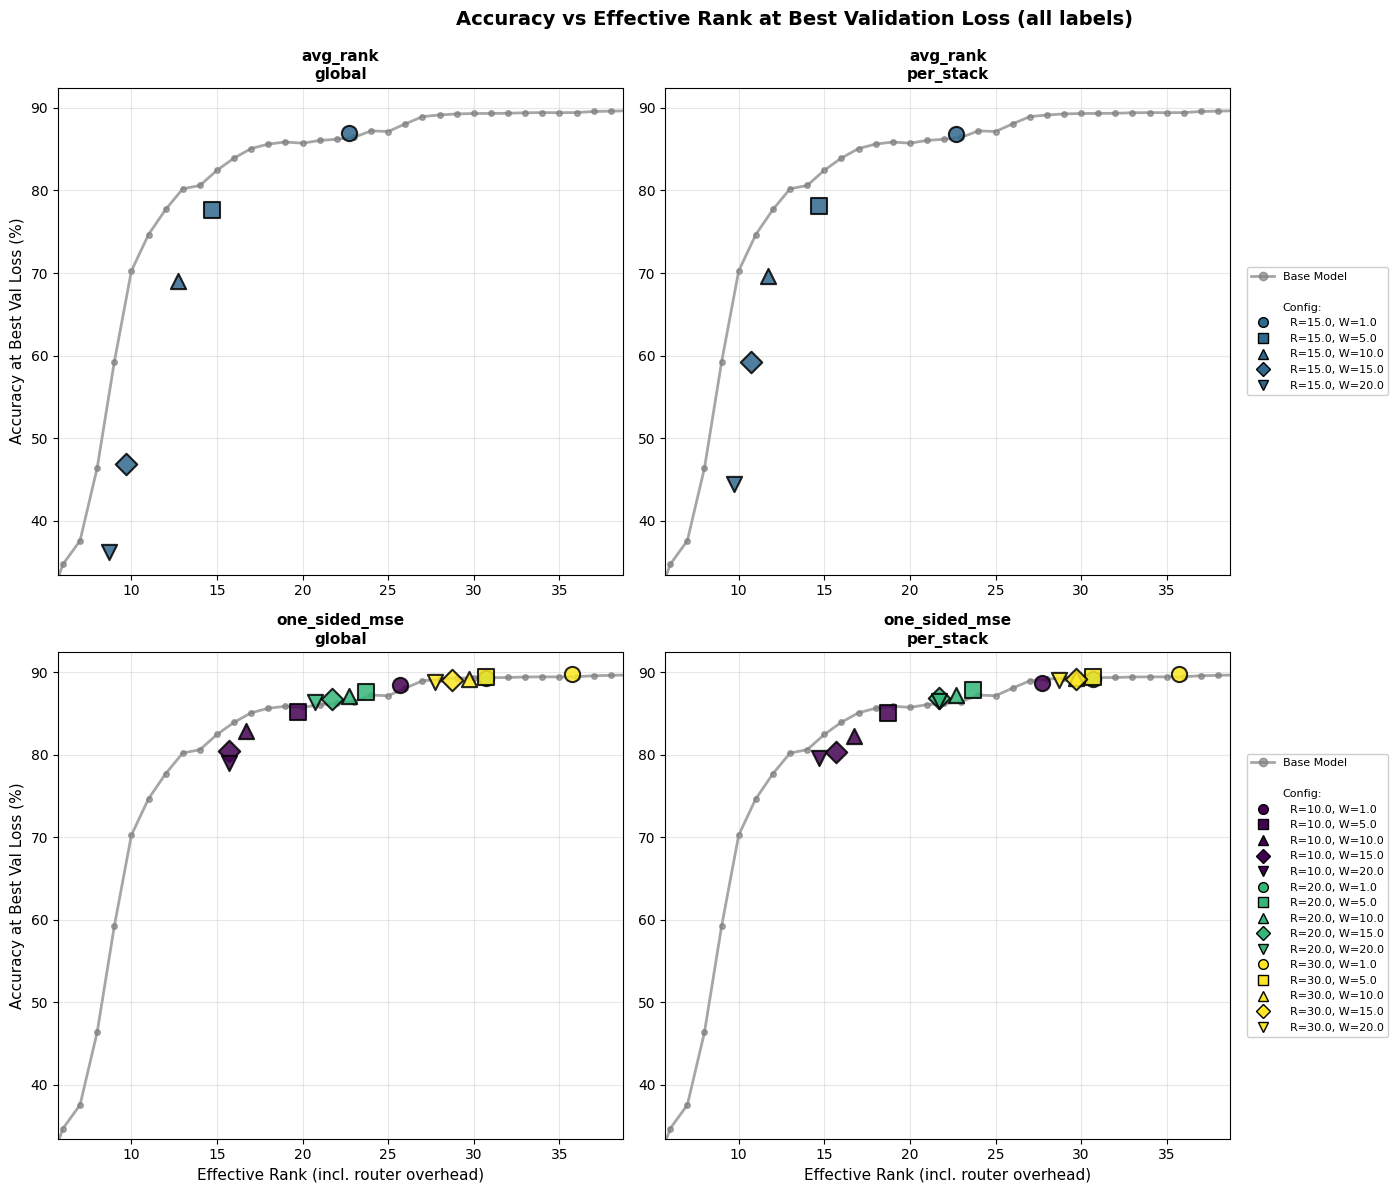

In [171]:
# Create the plot with effective rank (includes router overhead)
fig = plot_rank_vs_acc_by_mode(sweep_results, df_base=df_base, include_silence=True, use_effective_rank=True)
plt.show()

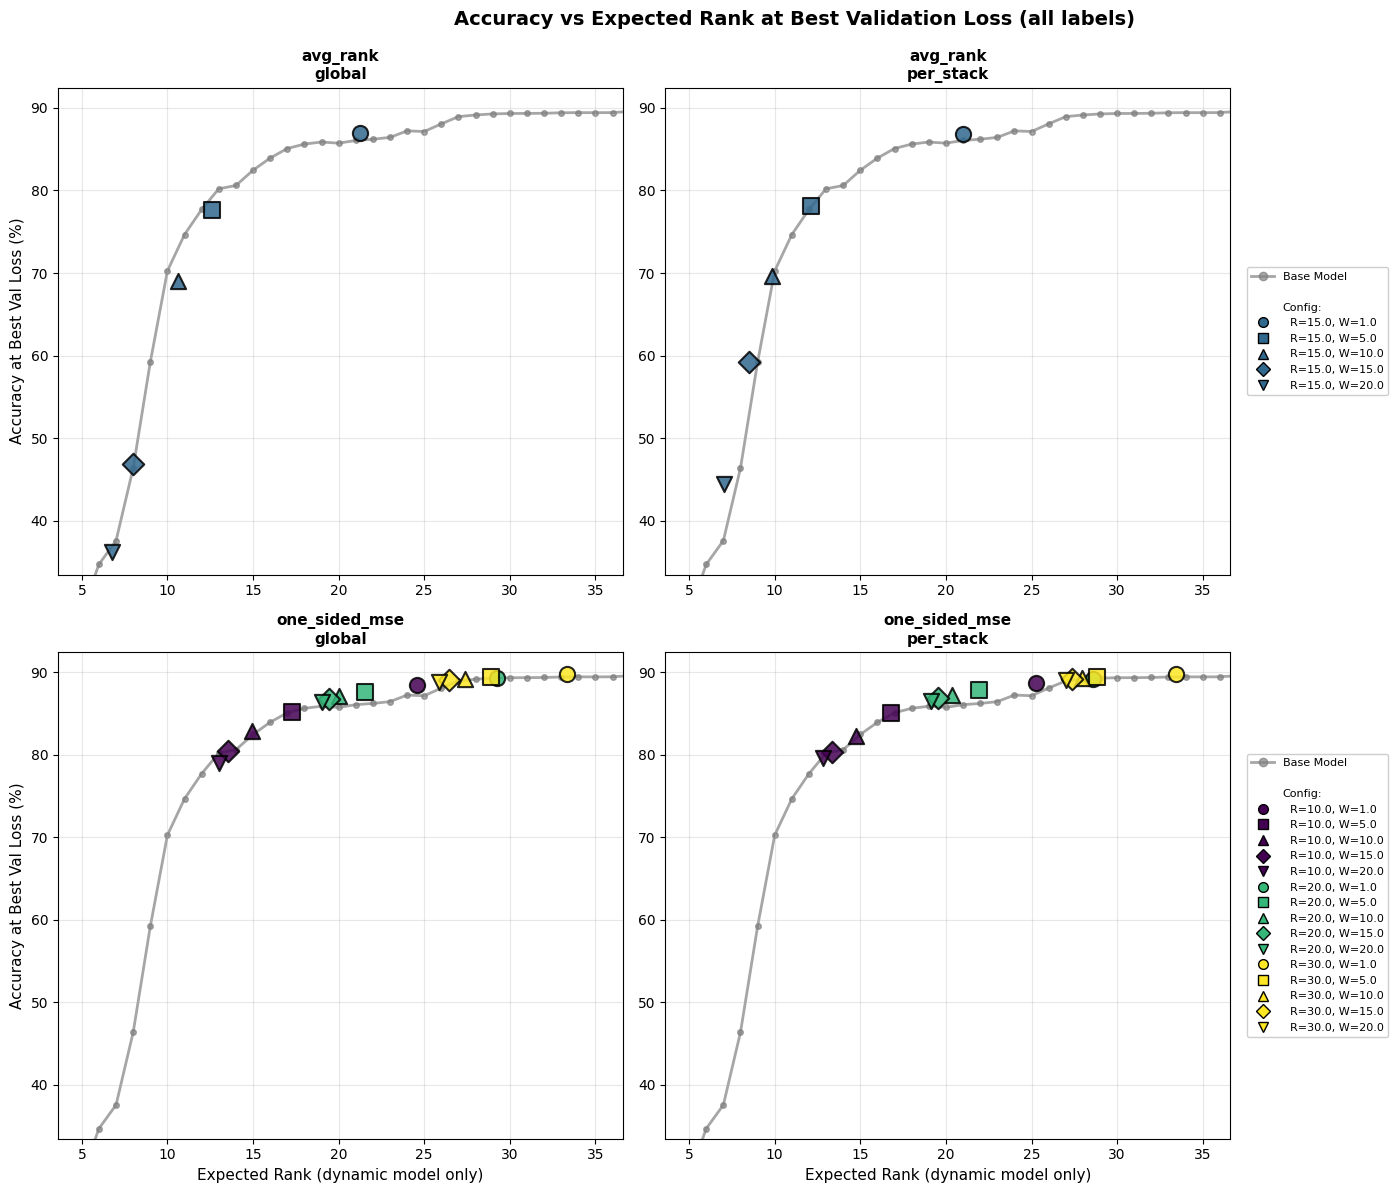

In [168]:
# Create the plot with expected rank only (dynamic model, no router overhead)
# This shows where the markers would be WITHOUT accounting for router cost
fig = plot_rank_vs_acc_by_mode(sweep_results, df_base=df_base, include_silence=True, use_effective_rank=False)
plt.show()

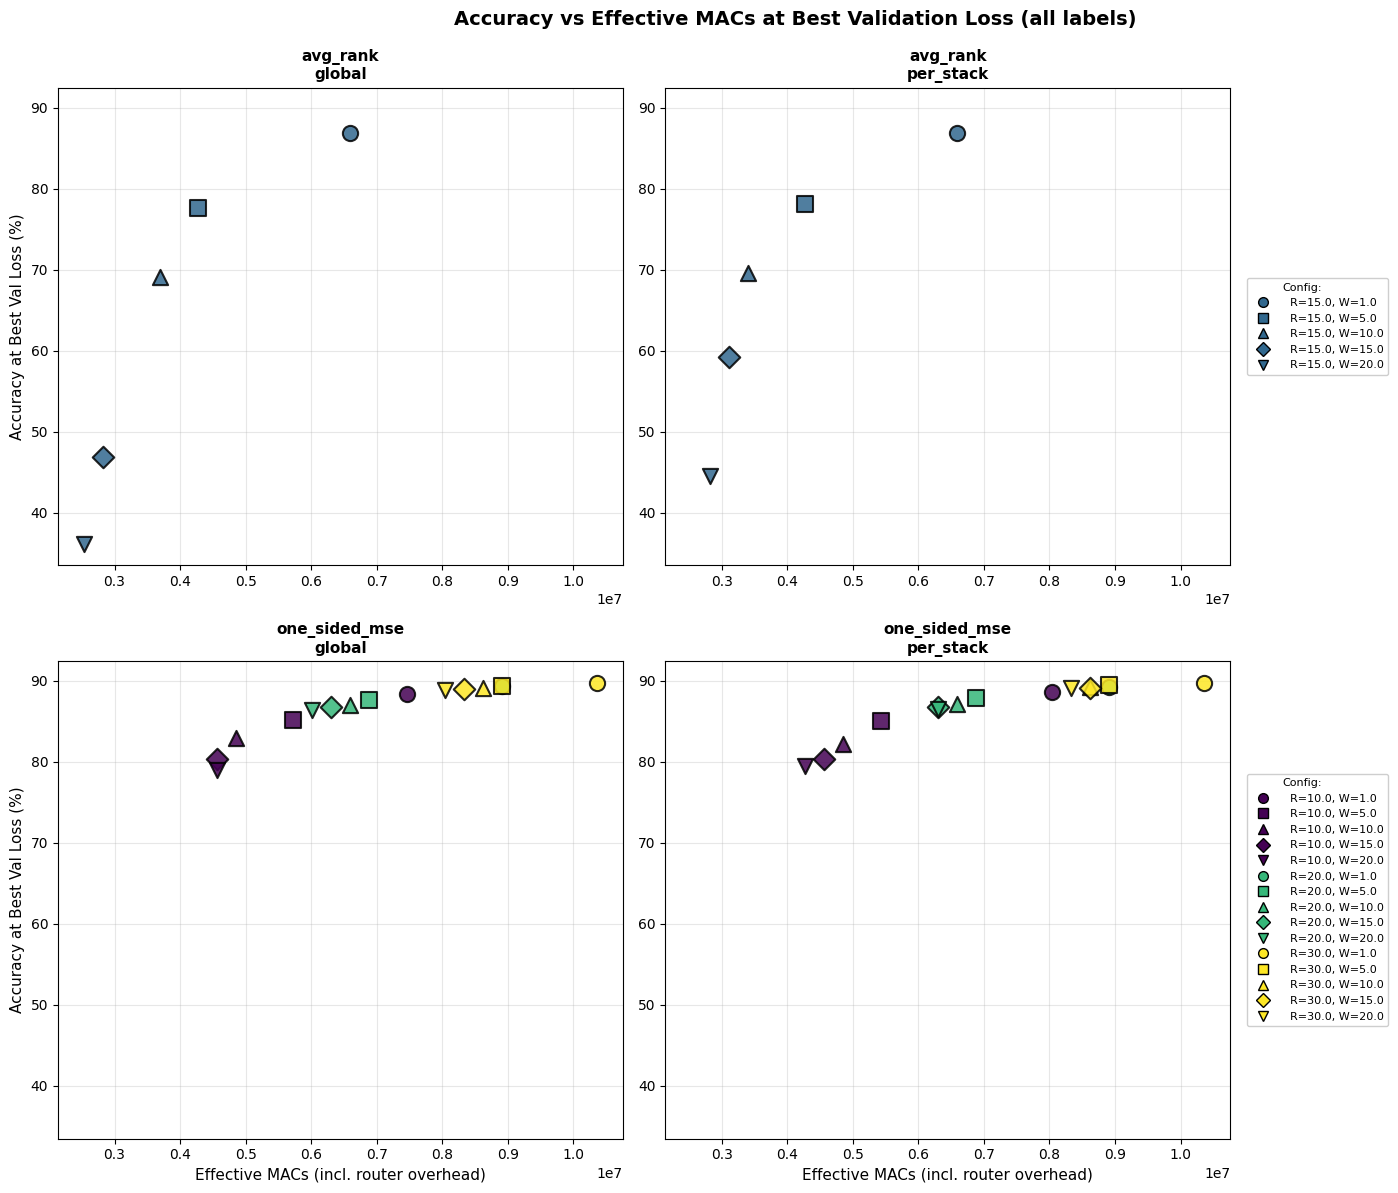

In [169]:
# Create plot with MACs on x-axis (effective MACs includes router overhead)
fig = plot_rank_vs_acc_by_mode(sweep_results, df_base=None, include_silence=True, use_effective_rank=True, x_axis='macs')
plt.show()